**PPE Detection on SH17 Dataset**

This notebook builds a high-performance PPE detection system using the SH17 dataset and YOLO11. The SH17 dataset contains ~8,099 images with annotations for 17 PPE classes (e.g., Helmet, Safety Vest). The process is broken into clear steps:
1. Data Collection
2. Environment Setup
3. Data Preprocessing and Augmentation
4. Exploratory Data Analysis
5. YOLO Dataset Preparation
6. Model Training
7. Evaluation and Visualization

**✅ 1. Persiapan Awal di Google Colab**

In [1]:
# import kagglehub
# mugheesahmad_sh17_dataset_for_ppe_detection_path = kagglehub.dataset_download('mugheesahmad/sh17-dataset-for|-ppe-detection')
# print('Data source import complete.')


# **🧩 Tahap 1 — Environment Setup & Data Collection**


##  **📦 1.1 Environment Setup**

Instalasi library dan verifikasi GPU environment di Kaggle

In [2]:
!pip install ultralytics albumentations seaborn --no-deps --no-cache-dir -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.7 MB/s eta 0:00:00a 0:00:01


In [3]:
print("🔧 Menginisialisasi environment...")

import os
import glob
import gc
import random
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tqdm.auto import tqdm
import shutil
from itertools import product

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Library tambahan
import cv2
import albumentations as A
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, display
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
from sklearn.preprocessing import MultiLabelBinarizer
from skmultilearn.model_selection import iterative_train_test_split
from collections import Counter
import ultralytics
import matplotlib.patches as patches

print("\n✅ Environment berhasil disiapkan.")
print(f" ├─ Torch version     : {torch.__version__}")
print(f" ├─ Ultralytics       : {ultralytics.__version__}")
print(f" └─ CUDA available    : {torch.cuda.is_available()}")

🔧 Menginisialisasi environment...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

✅ Environment berhasil disiapkan.
 ├─ Torch version     : 2.8.0+cu126
 ├─ Ultralytics       : 8.3.241
 └─ CUDA available    : True


## **🗂️ 1.2 Dataset Path & File Listing**

Menentukan direktori dataset SH17 dan menyiapkan list gambar & label

In [4]:
print("📂 Memuat dataset...")

DATASET_PATH = "/kaggle/input/sh17-dataset-for-ppe-detection"
image_dir = os.path.join(DATASET_PATH, "images")
label_dir = os.path.join(DATASET_PATH, "labels")

def list_images(path):
    return [
        os.path.join(dp, f)
        for dp, _, files in os.walk(path)
        for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

images = list_images(image_dir)
labels = [
    os.path.join(dp, f)
    for dp, _, fs in os.walk(label_dir)
    for f in fs if f.endswith(".txt")
]

print(f"🖼️ Jumlah gambar ditemukan : {len(images)}")
print(f"📄 Jumlah label ditemukan  : {len(labels)}")

📂 Memuat dataset...
🖼️ Jumlah gambar ditemukan : 8099
📄 Jumlah label ditemukan  : 8099


### 1.2.2 Validasi Format YOLO

In [5]:
valid_labels = []
print("\n🔍 Validating YOLO label format...\n")

for lbl in tqdm(labels, desc="Checking label format"):
    ok = True

    with open(lbl, "r") as f:
        for line in f:
            parts = line.strip().split()

            # Valid YOLO format: 5 elemen → class x y w h
            if len(parts) != 5:
                ok = False
                print(f"⚠️ Format salah → {lbl} → '{line.strip()}'")
                break

    if ok:
        valid_labels.append(lbl)

print(f"\n✅ Label valid: {len(valid_labels)} / {len(labels)}")


🔍 Validating YOLO label format...



Checking label format:   0%|          | 0/8099 [00:00<?, ?it/s]


✅ Label valid: 8099 / 8099


 **🔗 1.3 Pairing Images and Labels**

Mencocokkan file gambar dan label berdasarkan nama dasar (tanpa ekstensi)

In [6]:
print("🔗 Mencocokkan gambar dan label...")

image_map = {os.path.splitext(os.path.basename(f))[0]: f for f in images}
label_map = {os.path.splitext(os.path.basename(f))[0]: f for f in labels}

common = sorted(set(image_map.keys()) & set(label_map.keys()))
paired_images = [image_map[n] for n in common]
paired_labels = [label_map[n] for n in common]

print(f"✅ Total pasangan valid: {len(paired_images)}")

🔗 Mencocokkan gambar dan label...
✅ Total pasangan valid: 8099


split data bawaan dari dataset 

In [7]:
print("📑 Membaca pembagian dataset...")

with open(os.path.join(DATASET_PATH, "train_files.txt")) as f:
    train_imgs = f.read().splitlines()

with open(os.path.join(DATASET_PATH, "val_files.txt")) as f:
    val_imgs = f.read().splitlines()

ratio = len(train_imgs) / (len(train_imgs) + len(val_imgs))

print(f"🧪 Train      : {len(train_imgs)} data")
print(f"🧪 Validation : {len(val_imgs)} data")
print(f"📊 Rasio      : {ratio:.2f} / {(1-ratio):.2f}")

📑 Membaca pembagian dataset...
🧪 Train      : 6479 data
🧪 Validation : 1620 data
📊 Rasio      : 0.80 / 0.20


##  **🧹 1.4: Filter Valid PPE Annotations**

Menyaring hanya file label yang mengandung ID kelas PPE (0–16)dan memastikan format YOLO valid (5 nilai numerik)

In [8]:
print("🧹 Validasi dan penyaringan label...")

valid_images, valid_labels = [], []
allowed_classes = set(range(17))

def valid_label(line):
    parts = line.split()
    return len(parts) == 5 and int(parts[0]) in allowed_classes

for i, lbl in enumerate(paired_labels):
    with open(lbl) as f:
        lines = [l for l in f.read().splitlines() if l.strip() and valid_label(l)]
        if lines:
            valid_images.append(paired_images[i])
            valid_labels.append(lbl)

print(f"📌 Pasangan valid setelah filter: {len(valid_images)}")

🧹 Validasi dan penyaringan label...
📌 Pasangan valid setelah filter: 8099


##  **⚠️ 1.5: Check Invalid Labels**

Mengecek apakah ada file label dengan class ID di luar range 0–16

In [9]:
print("🔍 Memfilter anotasi label...")

ppe_class_ids = set(range(17))  
filtered_images = []
filtered_labels = []

def valid_label_line(line):
    """Validasi format YOLO: 1 class_id + 4 nilai bounding box float."""
    try:
        parts = list(map(float, line.split()))
        return len(parts) == 5 and all(0 <= v <= 1 for v in parts[1:])
    except:
        return False

for img_path, lbl_path in zip(paired_images, paired_labels):
    with open(lbl_path, "r") as f:
        lines = [l.strip() for l in f if l.strip()]

        valid_boxes = [
            l for l in lines
            if valid_label_line(l) and int(float(l.split()[0])) in ppe_class_ids
        ]

        if valid_boxes:  
            filtered_images.append(img_path)
            filtered_labels.append(lbl_path)

print(f"✅ Filter selesai: {len(filtered_labels)} label valid dari {len(paired_labels)} total.")

🔍 Memfilter anotasi label...
✅ Filter selesai: 8099 label valid dari 8099 total.


###   **✅ 1.6 Summary Log**

Menampilkan rekap hasil filter data sebelum EDA

In [10]:
print("\n📁 === Ringkasan Dataset ===")
print(f"Total gambar mentah   : {len(images)}")
print(f"Total label tersedia  : {len(labels)}")
print(f"Pasangan file cocok   : {len(paired_images)}")
print(f"Pasangan valid akhir  : {len(valid_images)}")
print("================================")

print("\n🔍 Contoh file valid:")
print("Image:", valid_images[0])
print("Label:", valid_labels[0])


📁 === Ringkasan Dataset ===
Total gambar mentah   : 8099
Total label tersedia  : 8099
Pasangan file cocok   : 8099
Pasangan valid akhir  : 8099

🔍 Contoh file valid:
Image: /kaggle/input/sh17-dataset-for-ppe-detection/images/building-construction-building-site-constructing.jpg
Label: /kaggle/input/sh17-dataset-for-ppe-detection/labels/building-construction-building-site-constructing.txt


# 📊 Tahap 2 — Exploratory Data Analysis (EDA)

In [11]:
print("\n=== 🔎 TAHAP 2: EXPLORATORY DATA ANALYSIS (EDA) ===\n")

# Dataset hasil filter dari Tahap 1:
# filtered_images, filtered_labels
print(f"Total gambar valid: {len(filtered_images)}")
print(f"Total label valid : {len(filtered_labels)}\n")


=== 🔎 TAHAP 2: EXPLORATORY DATA ANALYSIS (EDA) ===

Total gambar valid: 8099
Total label valid : 8099



## **🧾 2.1 Pemetaan Kelas**

Membaca daftar nama kelas dari meta-data atau menggunakan fallback dictionary.

In [12]:
print("📄 Memuat daftar kelas...")

meta_path = os.path.join(DATASET_PATH, "meta-data", "classes.txt")

if os.path.exists(meta_path):
    with open(meta_path, "r") as f:
        class_list = [line.strip() for line in f if line.strip()]
        class_names = {i: name for i, name in enumerate(class_list)}
else:
    # Default class list berdasarkan dokumentasi SH17
    class_names = {
        0: "person", 1: "ear", 2: "ear-mufs", 3: "face", 4: "face-guard",
        5: "face-mask", 6: "foot", 7: "tool", 8: "glasses", 9: "gloves",
        10: "helmet", 11: "hands", 12: "head", 13: "medical-suit",
        14: "shoes", 15: "safety-suit", 16: "safety-vest"
    }

print(f"✅ Jumlah kelas terdeteksi: {len(class_names)} kelas\n")
print("📝 Daftar kelas:")
for cid, cname in class_names.items():
    print(f" - {cid}: {cname}")

📄 Memuat daftar kelas...
✅ Jumlah kelas terdeteksi: 17 kelas

📝 Daftar kelas:
 - 0: person
 - 1: ear
 - 2: ear-mufs
 - 3: face
 - 4: face-guard
 - 5: face-mask
 - 6: foot
 - 7: tool
 - 8: glasses
 - 9: gloves
 - 10: helmet
 - 11: hands
 - 12: head
 - 13: medical-suit
 - 14: shoes
 - 15: safety-suit
 - 16: safety-vest


## 🔢 **2.2. Distribusi Kelas**

Menghitung jumlah instance tiap kelas dari semua file labeldan memvisualisasikan hasilnya dalam bentuk bar chart.

In [13]:
print("\n📊 Menghitung distribusi kelas...")

all_class_ids = []

for lbl in tqdm(filtered_labels, desc="Processing labels"):
    with open(lbl) as f:
        for line in f:
            parts = line.split()
            if parts:
                try:
                    all_class_ids.append(int(float(parts[0])))
                except:
                    pass

class_counts = Counter(all_class_ids)

class_df = pd.DataFrame({
    "Class_ID": list(class_counts.keys()),
    "Count": list(class_counts.values())
}).sort_values("Class_ID")

class_df["Class_Name"] = class_df["Class_ID"].apply(lambda x: class_names[x])

print("\n📌 Ringkasan distribusi kelas:")
display(class_df)


📊 Menghitung distribusi kelas...


Processing labels:   0%|          | 0/8099 [00:00<?, ?it/s]


📌 Ringkasan distribusi kelas:


,Class_ID,Count,Class_Name
5,0,13802,person
9,1,7730,ear
13,2,318,ear-mufs
8,3,8950,face
14,4,134,face-guard
12,5,670,face-mask
15,6,759,foot
6,7,4647,tool
11,8,1945,glasses
0,9,2790,gloves


## 📊 2.3 Visualisasi Distribusi Kelas

Menampilkan distribusi jumlah data per kelas dengan persentase.


📈 Visualisasi distribusi kelas...


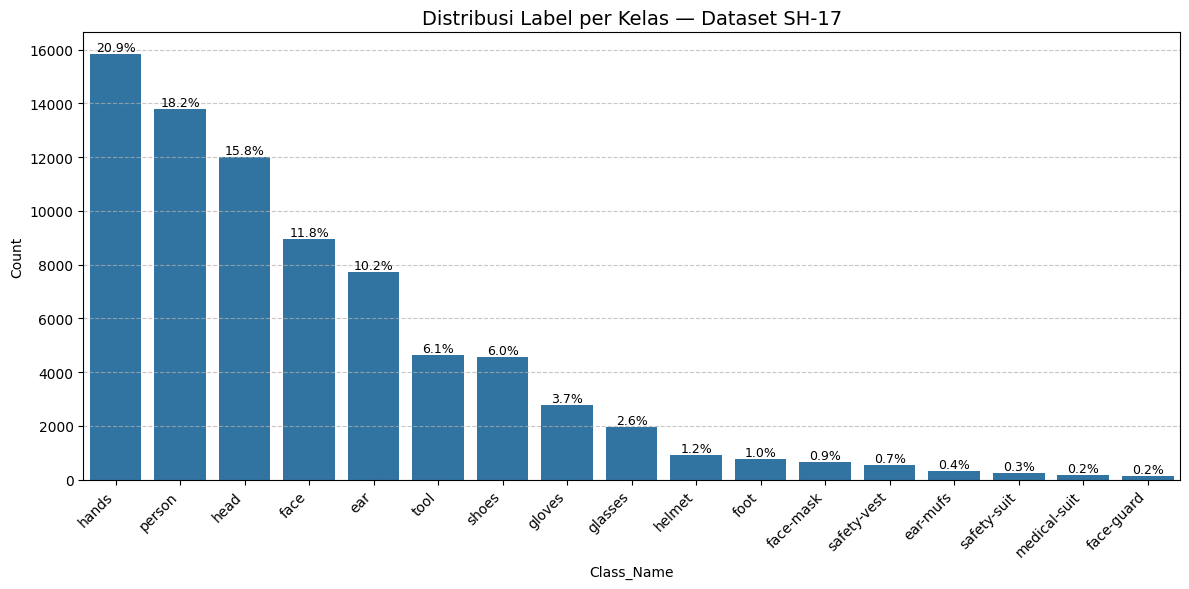

In [14]:
print("\n📈 Visualisasi distribusi kelas...")

def plot_distribution(df):
    total = df["Count"].sum()
    df = df.sort_values("Count", ascending=False)

    plt.figure(figsize=(12,6))
    bar = sns.barplot(x="Class_Name", y="Count", data=df)

    plt.title("Distribusi Label per Kelas — Dataset SH-17", fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Persentase di atas bar
    for p in bar.patches:
        percentage = f"{(p.get_height()/total)*100:.1f}%"
        bar.annotate(
            percentage,
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center", va="bottom", fontsize=9
        )

    plt.tight_layout()
    plt.show()

plot_distribution(class_df)

## **📐 2.4 Analisis Ukuran Gambar**

Mengecek distribusi resolusi dengan sample acak agar cepat.


📐 Menganalisis resolusi gambar...
📊 Sampel dianalisis : 300 gambar
📌 Resolusi rata-rata: 4904.2 × 4560.7
📌 Resolusi minimum  : 1989 × 2000
📌 Resolusi maksimum : 8192 × 8192


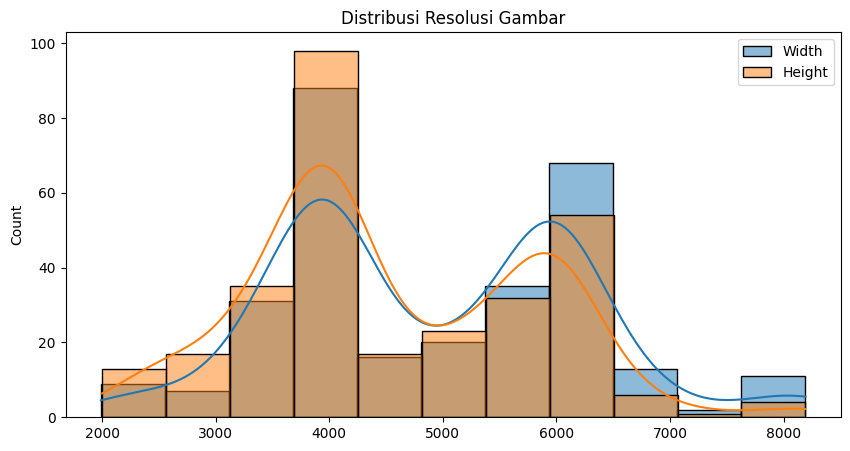

In [15]:
print("\n📐 Menganalisis resolusi gambar...")

sample_size = min(300, len(filtered_images))
sample = random.sample(filtered_images, sample_size)

widths, heights = [], []

for img in sample:
    arr = cv2.imread(img)
    if arr is not None:
        h, w = arr.shape[:2]
        widths.append(w)
        heights.append(h)

print(f"📊 Sampel dianalisis : {sample_size} gambar")
print(f"📌 Resolusi rata-rata: {np.mean(widths):.1f} × {np.mean(heights):.1f}")
print(f"📌 Resolusi minimum  : {min(widths)} × {min(heights)}")
print(f"📌 Resolusi maksimum : {max(widths)} × {max(heights)}")

plt.figure(figsize=(10,5))
sns.histplot(widths, label="Width", kde=True)
sns.histplot(heights, label="Height", kde=True)
plt.legend()
plt.title("Distribusi Resolusi Gambar")
plt.show()

## 📌 2.5 Statistik BBox (Analisis W & H)


📏 Menganalisis ukuran bounding box...


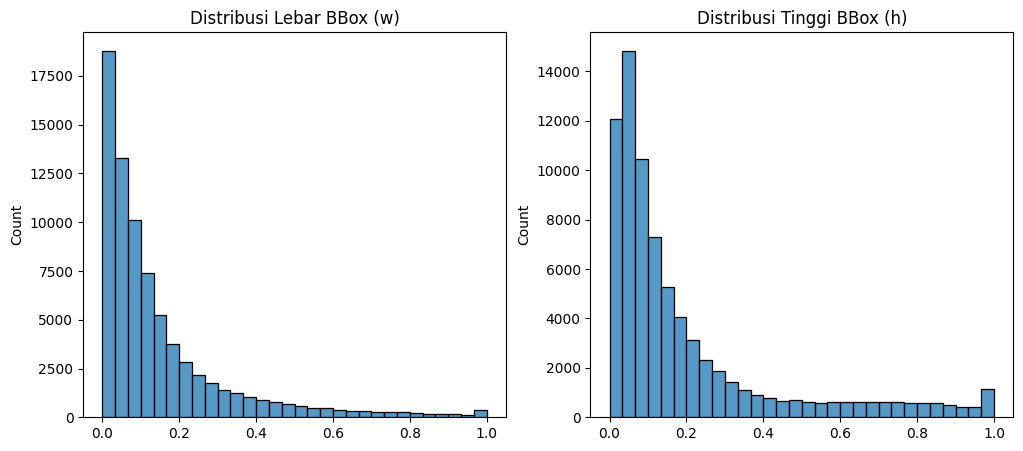

⚠️ BBox terlalu kecil (w < 0.01): 4671
⚠️ BBox terlalu kecil (h < 0.01): 1869


In [16]:
print("\n📏 Menganalisis ukuran bounding box...")

ws, hs = [], []

for lbl in filtered_labels:
    with open(lbl, "r") as f:
        for line in f:
            _, x, y, w, h = map(float, line.split())
            ws.append(w)
            hs.append(h)

plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
sns.histplot(ws, bins=30)
plt.title("Distribusi Lebar BBox (w)")

plt.subplot(1, 2, 2)
sns.histplot(hs, bins=30)
plt.title("Distribusi Tinggi BBox (h)")
plt.show()

small_w = sum(1 for w in ws if w < 0.01)
small_h = sum(1 for h in hs if h < 0.01)

print(f"⚠️ BBox terlalu kecil (w < 0.01): {small_w}")
print(f"⚠️ BBox terlalu kecil (h < 0.01): {small_h}")

## **🖼️ 2.6. Contoh Gambar dengan Anotasi Bounding Box**

Menampilkan anotasi YOLO dalam format bounding box berwarna.


🖼️ Menampilkan contoh anotasi bounding box...


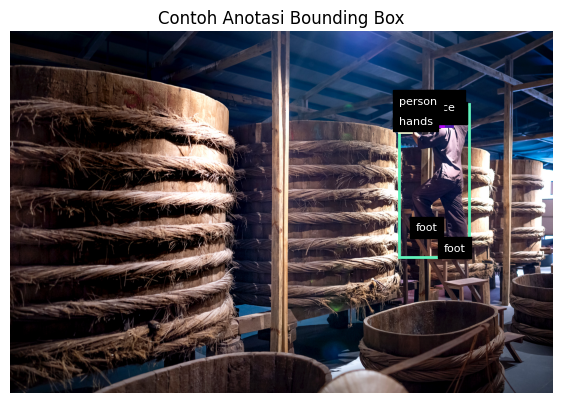


=== ✅ TAHAP 2 (EDA) SELESAI ===



In [14]:
print("\n🖼️ Menampilkan contoh anotasi bounding box...")

colors = {cid: tuple(np.random.rand(3)) for cid in class_names.keys()}

def show_sample(idx=None):
    if idx is None:
        idx = random.randint(0, len(filtered_images)-1)

    img_path = filtered_images[idx]
    lbl_path = filtered_labels[idx]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    fig, ax = plt.subplots(1, figsize=(7,7))
    ax.imshow(img)

    with open(lbl_path) as f:
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.split())
            x1 = (xc - bw/2) * w
            y1 = (yc - bh/2) * h

            rect = patches.Rectangle(
                (x1,y1), bw*w, bh*h,
                linewidth=2, edgecolor=colors[int(cls)], facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(
                x1, y1-4, class_names[int(cls)],
                color="white", fontsize=8, backgroundcolor="black"
            )

    plt.title("Contoh Anotasi Bounding Box")
    plt.axis("off")
    plt.show()

show_sample()

print("\n=== ✅ TAHAP 2 (EDA) SELESAI ===\n")

Penjelasan:
- Menampilkan satu gambar dengan anotasi bounding box.
- Kotak dan label dikonversi dari format YOLO.

Alasan:
- Visualisasi ini sangat penting untuk memastikan file label benar dan sesuai objek.

# 🧩 Tahap 3 — Data Preprocessing & Augmentation (Oversampling RFS)

🎯 Tujuan:.

## **3.1. Data splitting**

---
Multi-label Stratified

In [15]:
print("\n🔎 Creating Train/Val/Test Split...")

# Build map from image_id -> label_path
labels = sorted(glob.glob(label_dir + "/*.txt"))

label_map = {
    os.path.splitext(os.path.basename(p))[0]: p
    for p in labels
}

# Filter existing train images only if label exists
train_set = [
    p for p in train_imgs
    if os.path.splitext(os.path.basename(p))[0] in label_map
]

valtest_pool = [
    p for p in val_imgs
    if os.path.splitext(os.path.basename(p))[0] in label_map
]

train_labels_set = [
    label_map[os.path.splitext(os.path.basename(p))[0]]
    for p in train_set
]

valtest_labels_set = [
    label_map[os.path.splitext(os.path.basename(p))[0]]
    for p in valtest_pool
]

# Extract class list from each label
y = []
for lbl in valtest_labels_set:
    with open(lbl) as f:
        classes = list(set(
            int(float(line.split()[0]))
            for line in f if line.strip()
        ))
    y.append(classes)

mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(y)
X = np.array(valtest_pool).reshape(-1, 1)

X_val, Y_val, X_test, Y_test = iterative_train_test_split(
    X, Y, test_size=0.5
)

val_imgs  = X_val.flatten().tolist()
test_imgs = X_test.flatten().tolist()

val_labels  = [
    label_map[os.path.splitext(os.path.basename(p))[0]]
    for p in val_imgs
]
test_labels = [
    label_map[os.path.splitext(os.path.basename(p))[0]]
    for p in test_imgs
]

print("✔ Train =", len(train_set))
print("✔ Val   =", len(val_imgs))
print("✔ Test  =", len(test_imgs))



🔎 Creating Train/Val/Test Split...
✔ Train = 6479
✔ Val   = 807
✔ Test  = 813


### **3.1.2 Sebaran Splitting data**

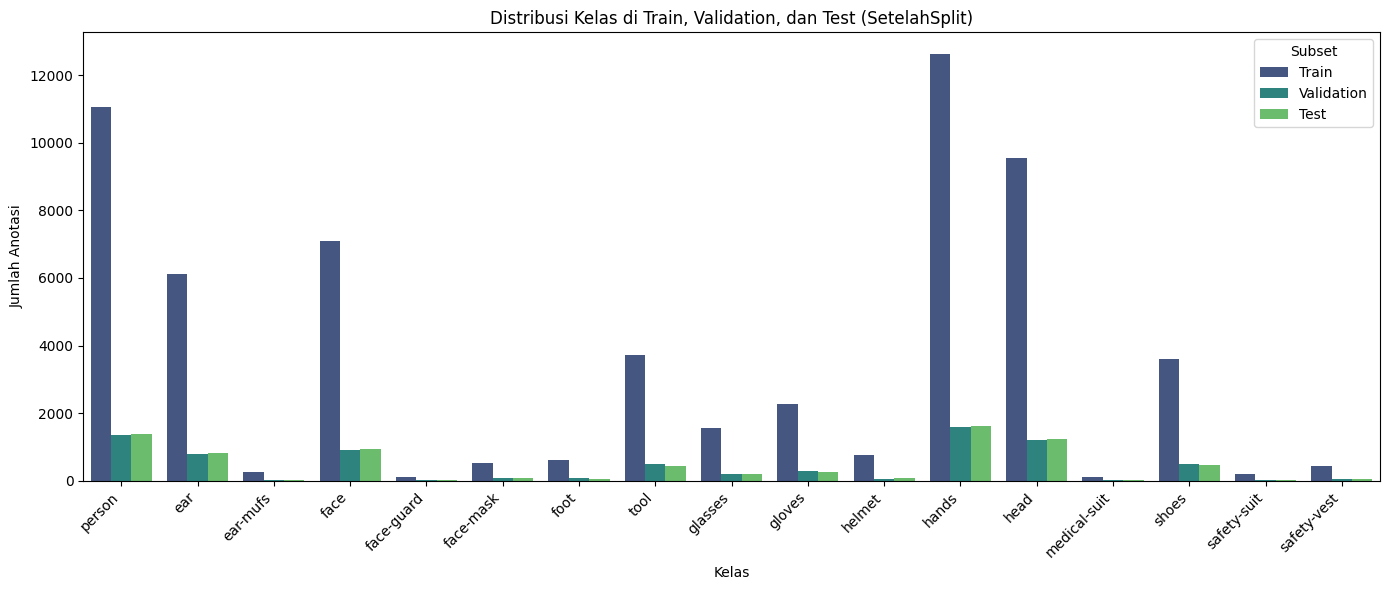

✔ Distribusi train labels: 60636
✔ Distribusi val labels  : 7643
✔ Distribusi test labels : 7715
📊 DONE: Distribusi Kelas setelah splitting dibuat.


In [16]:
def get_class_distribution(label_paths, class_names):
    counts = Counter()
    for f in label_paths:
        with open(f, 'r') as file:
            for line in file:
                parts = line.strip().split()
                if parts:
                    cls = int(float(parts[0]))
                    counts[cls] += 1
    return counts

# Hitung distribusi
train_dist = get_class_distribution(train_labels_set, class_names)
val_dist   = get_class_distribution(val_labels, class_names)
test_dist  = get_class_distribution(test_labels, class_names)

# Buat DataFrame
dist_df = pd.DataFrame({
    'Train': [train_dist.get(i, 0) for i in class_names.keys()],
    'Validation': [val_dist.get(i, 0) for i in class_names.keys()],
    'Test': [test_dist.get(i, 0) for i in class_names.keys()],
}, index=[class_names[i] for i in class_names.keys()])

# Untuk plot
dist_melted = dist_df.reset_index().rename(columns={'index':'Class'}).melt(
    id_vars='Class', var_name='Subset', value_name='Count')

plt.figure(figsize=(14,6))
sns.barplot(data=dist_melted, x='Class', y='Count', hue='Subset', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Kelas")
plt.ylabel("Jumlah Anotasi")
plt.title("Distribusi Kelas di Train, Validation, dan Test (SetelahSplit)")
plt.legend(title='Subset')
plt.tight_layout()
plt.show()

print(f"✔ Distribusi train labels: {sum(train_dist.values())}")
print(f"✔ Distribusi val labels  : {sum(val_dist.values())}")
print(f"✔ Distribusi test labels : {sum(test_dist.values())}")


print("📊 DONE: Distribusi Kelas setelah splitting dibuat.")


## **🔁 3.3 — Analisis Ketidakseimbangan Dataset**

identifikasi kelas minoritas yang perlu diover-sample.

### 🔧 3.3.1 Hitung Distribusi Train / Val / Test

In [17]:
from collections import Counter

def get_class_distribution(label_paths):
    counts = Counter()
    for f in label_paths:
        with open(f, "r") as file:
            for line in file:
                cls = int(float(line.split()[0]))
                counts[cls] += 1
    return counts

train_dist = get_class_distribution(train_labels_set)
val_dist   = get_class_distribution(val_labels)
test_dist  = get_class_distribution(test_labels)

dist_df = pd.DataFrame({
    "Train": [train_dist.get(i,0) for i in class_names.keys()],
    "Val":   [val_dist.get(i,0) for i in class_names.keys()],
    "Test":  [test_dist.get(i,0) for i in class_names.keys()],
}, index=[class_names[i] for i in class_names.keys()])

display(dist_df)


,Train,Val,Test
person,11068,1355,1379
ear,6118,791,821
ear-mufs,269,25,24
face,7095,917,938
face-guard,110,11,13
face-mask,519,71,80
foot,610,86,63
tool,3724,492,431
glasses,1547,195,203
gloves,2261,276,253


### 🔧 3.3.2 Distribusi Total per Kelas

In [18]:
total_dist = {cid:train_dist.get(cid,0)+val_dist.get(cid,0)+test_dist.get(cid,0) for cid in class_names}

imbalance_df = pd.DataFrame({
    "Class_ID": list(class_names.keys()),
    "Class_Name": [class_names[cid] for cid in class_names.keys()],
    "Train": [train_dist.get(cid,0) for cid in class_names.keys()],
    "Validation": [val_dist.get(cid,0) for cid in class_names.keys()],
    "Test": [test_dist.get(cid,0) for cid in class_names.keys()],
    "Total": [total_dist[cid] for cid in class_names.keys()]
}).sort_values("Total", ascending=False)

display(imbalance_df)

,Class_ID,Class_Name,Train,Validation,Test,Total
11,11,hands,12638,1587,1625,15850
0,0,person,11068,1355,1379,13802
12,12,head,9558,1206,1221,11985
3,3,face,7095,917,938,8950
1,1,ear,6118,791,821,7730
7,7,tool,3724,492,431,4647
14,14,shoes,3604,480,476,4560
9,9,gloves,2261,276,253,2790
8,8,glasses,1547,195,203,1945
10,10,helmet,773,60,94,927


### 🔧 3.3.4 Identifikasi Kelas Mayor & Minor

In [19]:
total_dist = {
    cid: train_dist.get(cid,0) + val_dist.get(cid,0) + test_dist.get(cid,0)
    for cid in class_names.keys()
}

imbalance_df = pd.DataFrame({
    "Class_ID": list(class_names.keys()),
    "Class_Name": [class_names[cid] for cid in class_names.keys()],
    "Train": [train_dist.get(cid,0) for cid in class_names.keys()],
    "Val":   [val_dist.get(cid,0)  for cid in class_names.keys()],
    "Test":  [test_dist.get(cid,0)  for cid in class_names.keys()],
    "Total": [total_dist[cid]       for cid in class_names.keys()],
}).sort_values("Total", ascending=False)

display(imbalance_df)

avg_annotations = imbalance_df["Total"].mean()
print("Mayoritas kelas:")
display(imbalance_df[imbalance_df["Total"] > avg_annotations])

print("Minoritas kelas:")
display(imbalance_df[imbalance_df["Total"] < avg_annotations])


,Class_ID,Class_Name,Train,Val,Test,Total
11,11,hands,12638,1587,1625,15850
0,0,person,11068,1355,1379,13802
12,12,head,9558,1206,1221,11985
3,3,face,7095,917,938,8950
1,1,ear,6118,791,821,7730
7,7,tool,3724,492,431,4647
14,14,shoes,3604,480,476,4560
9,9,gloves,2261,276,253,2790
8,8,glasses,1547,195,203,1945
10,10,helmet,773,60,94,927


Mayoritas kelas:


,Class_ID,Class_Name,Train,Val,Test,Total
11,11,hands,12638,1587,1625,15850
0,0,person,11068,1355,1379,13802
12,12,head,9558,1206,1221,11985
3,3,face,7095,917,938,8950
1,1,ear,6118,791,821,7730
7,7,tool,3724,492,431,4647
14,14,shoes,3604,480,476,4560


Minoritas kelas:


,Class_ID,Class_Name,Train,Val,Test,Total
9,9,gloves,2261,276,253,2790
8,8,glasses,1547,195,203,1945
10,10,helmet,773,60,94,927
6,6,foot,610,86,63,759
5,5,face-mask,519,71,80,670
16,16,safety-vest,433,43,54,530
2,2,ear-mufs,269,25,24,318
15,15,safety-suit,195,20,25,240
13,13,medical-suit,114,28,15,157
4,4,face-guard,110,11,13,134


## **📊 3.4 — Hitung Frekuensi Kelas untuk RFS (Training Set)**

Menghitung rasio jumlah gambar yang mengandung setiap kelas terhadap total gambar training. Ini adalah langkah pertama dalam perhitungan Repeat Factor Sampling (RFS).

In [20]:
total_train_images = len(train_set)
class_image_counts = Counter()

for img_path, lbl_path in tqdm(zip(train_set, train_labels_set), total=total_train_images):
    classes = set()
    with open(lbl_path) as f:
        for line in f:
            cls = int(float(line.split()[0]))
            classes.add(cls)
    for cid in classes:
        class_image_counts[cid] += 1

class_frequencies = {
    cid: class_image_counts[cid] / total_train_images
    for cid in class_image_counts
}

print("📌 Frekuensi kelas fc:")
for cid, freq in sorted(class_frequencies.items()):
    print(f"- {class_names[cid]}: {freq:.6f}")


  0%|          | 0/6479 [00:00<?, ?it/s]

📌 Frekuensi kelas fc:
- person: 0.941812
- ear: 0.601482
- ear-mufs: 0.028554
- face: 0.693163
- face-guard: 0.016052
- face-mask: 0.049390
- foot: 0.043680
- tool: 0.278129
- glasses: 0.195246
- gloves: 0.164686
- helmet: 0.057571
- hands: 0.798117
- head: 0.799660
- medical-suit: 0.012965
- shoes: 0.192931
- safety-suit: 0.017441
- safety-vest: 0.025930


## **🔢 3.5 — Hitung Faktor Pengulangan (rc & ri)**

Menghitung faktor pengulangan untuk setiap kelas (`rc`) dan setiap gambar (`ri`) berdasarkan frekuensi kelas dan nilai threshold `t`.

In [21]:
t = 0.05
category_repeat_factors = {}

for cid, freq in class_frequencies.items():
    rc = max(1.0, t/freq)
    category_repeat_factors[cid] = rc

print("\n📌 Category Repeat Factor (rc):")
for cid, rc in category_repeat_factors.items():
    print(f"- {class_names[cid]}: {rc:.3f}")


image_repeat_factors = {}

for img, lbl in tqdm(zip(train_set, train_labels_set), total=len(train_set)):
    classes = set()
    with open(lbl) as f:
        for line in f:
            cls = int(float(line.split()[0]))
            classes.add(cls)

    ri = max(category_repeat_factors[c] for c in classes) if classes else 1.0
    image_repeat_factors[img] = ri

print("\n📌 Contoh ri:")
list(image_repeat_factors.items())[:10]



📌 Category Repeat Factor (rc):
- person: 1.000
- ear: 1.000
- face: 1.000
- foot: 1.145
- hands: 1.000
- head: 1.000
- tool: 1.000
- face-mask: 1.012
- gloves: 1.000
- glasses: 1.000
- helmet: 1.000
- shoes: 1.000
- ear-mufs: 1.751
- face-guard: 3.115
- safety-vest: 1.928
- medical-suit: 3.857
- safety-suit: 2.867


  0%|          | 0/6479 [00:00<?, ?it/s]


📌 Contoh ri:


[('pexels-photo-16468065.jpeg', 1.1446996466431096),
 ('pexels-photo-4219650.jpeg', 1.0),
 ('pexels-photo-8948288.jpeg', 1.01234375),
 ('pexels-photo-8985515.jpeg', 1.0),
 ('pexels-photo-5999817.jpeg', 1.0),
 ('pexels-photo-5410093.jpeg', 1.0),
 ('pexels-photo-8961522.jpeg', 1.0),
 ('pexels-photo-8938643.jpeg', 1.0),
 ('pexels-photo-5414335.jpeg', 1.0),
 ('pexels-photo-5641937.jpeg', 1.0)]

## **🔄 3.6 — Buat Daftar Data Training RFS**

Membuat daftar file gambar dan label training yang diulang berdasarkan faktor pengulangan gambar (`ri`) untuk diterapkan pada proses data loading YOLO.

In [22]:
import math

print("🔄 Applying RFS...")

rfs_train_images = []
rfs_train_labels = []

map_lbl = dict(zip(train_set, train_labels_set))

for img, ri in image_repeat_factors.items():
    rep = max(1, math.ceil(ri))
    lbl = map_lbl[img]
    for _ in range(rep):
        rfs_train_images.append(img)
        rfs_train_labels.append(lbl)

print("🔥 Original train size:", len(train_set))
print("🔥 RFS train size     :", len(rfs_train_images))

🔄 Applying RFS...
🔥 Original train size: 6479
🔥 RFS train size     : 8055


## **📊 3.7 Visualisasi Distribusi Kelas setelah RFS**

Menampilkan distribusi jumlah anotasi per kelas di dataset training yang sudah di-Repeat Factor Sampling (RFS) untuk memverifikasi efek oversampling.

### **📊 3.7.1 Distribusi Kelas — Before vs After RFS (Tabel)**

In [23]:
orig = Counter()
rfs  = Counter()

for lbl in train_labels_set:
    with open(lbl) as f:
        for line in f:
            orig[int(float(line.split()[0]))] += 1

for lbl in rfs_train_labels:
    with open(lbl) as f:
        for line in f:
            rfs[int(float(line.split()[0]))] += 1

compare_df = pd.DataFrame({
    "Class_ID": list(class_names.keys()),
    "Class_Name": [class_names[c] for c in class_names.keys()],
    "Before": [orig[c] for c in class_names.keys()],
    "After" : [rfs[c]  for c in class_names.keys()],
})

compare_df["Increase"] = compare_df["After"] - compare_df["Before"]
compare_df["Increase(%)"] = compare_df["Increase"] / compare_df["Before"] * 100

display(compare_df)


,Class_ID,Class_Name,Before,After,Increase,Increase(%)
0,0,person,11068,14240,3172,28.659198
1,1,ear,6118,7507,1389,22.703498
2,2,ear-mufs,269,554,285,105.947955
3,3,face,7095,8435,1340,18.886540
4,4,face-guard,110,440,330,300.000000
5,5,face-mask,519,1188,669,128.901734
6,6,foot,610,1233,623,102.131148
7,7,tool,3724,5378,1654,44.414608
8,8,glasses,1547,2047,500,32.320621
9,9,gloves,2261,3589,1328,58.735073


## **📈 3.7.2 Grafik Perbandingan Before vs After RFS**


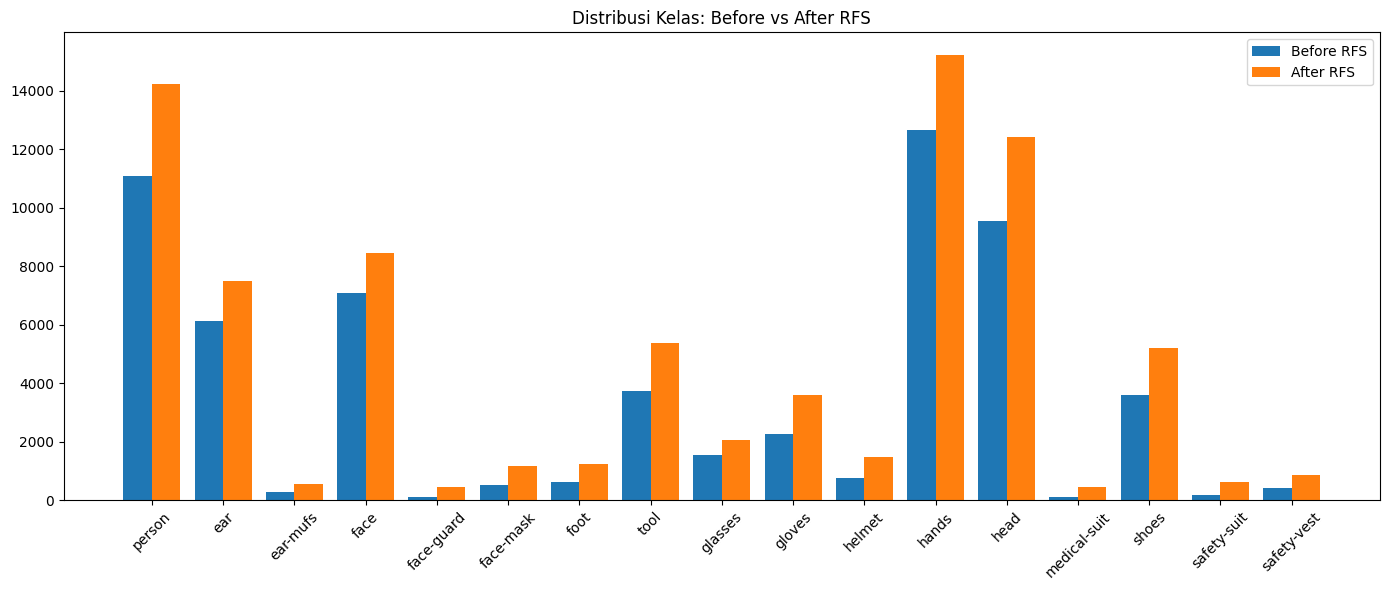

In [24]:
plt.figure(figsize=(14,6))

x = range(len(compare_df))
bw = 0.4

plt.bar(x, compare_df["Before"], width=bw, label="Before RFS")
plt.bar([i+bw for i in x], compare_df["After"], width=bw, label="After RFS")

plt.xticks([i+bw/2 for i in x], compare_df["Class_Name"], rotation=45)
plt.legend()
plt.title("Distribusi Kelas: Before vs After RFS")
plt.tight_layout()
plt.show()


## **🔧 3.8 —Rebuild valid absolute paths (Fix YOLO error)**


In [25]:
print("🔧 Fixing dataset paths for YOLO...")

IMG_ROOT = f"{DATASET_PATH}/images"

def make_paths(lst):
    fixed=[]
    for p in lst:
        base = os.path.basename(p)
        new = os.path.join(IMG_ROOT, base)
        if os.path.exists(new):
            fixed.append(new)
    return fixed

fixed_train = make_paths(rfs_train_images)
fixed_val   = make_paths(val_imgs)
fixed_test  = make_paths(test_imgs)

print("🔥 Final valid:")
print("Train:", len(fixed_train))
print("Val:",   len(fixed_val))
print("Test:",  len(fixed_test))


🔧 Fixing dataset paths for YOLO...
🔥 Final valid:
Train: 8055
Val: 807
Test: 813


## **🔧 🔥 3.9 Save TXT lists dan YAML**

Membuat file YAML baru untuk konfigurasi dataset yang akan digunakan YOLOv11, menunjuk ke daftar file training yang sudah disampling dengan RFS.

In [26]:
print("💾 Saving dataset lists...")

root="/kaggle/working"
def save(lst,name):
    with open(f"{root}/{name}","w") as f:
        f.write("\n".join(lst))

save(fixed_train,"train.txt")
save(fixed_val,"val.txt")
save(fixed_test,"test.txt")

yaml="/kaggle/working/ppe_dataset_rfs.yaml"

text=f"""
path: /kaggle/working

train: train.txt
val: val.txt
test: test.txt

nc: {len(class_names)}
names:
"""

for cid,name in class_names.items():
    text+=f"  {cid}: {name}\n"

with open(yaml,"w") as f:
    f.write(text.strip())

print("✔ TXT + YAML saved")


💾 Saving dataset lists...
✔ TXT + YAML saved


In [27]:
print("🔎 Final dataset validation...")

assert all(os.path.exists(p) for p in fixed_train)
assert all(os.path.exists(p) for p in fixed_val)
assert all(os.path.exists(p) for p in fixed_test)

print("🎉 Dataset VALID — siap training!")


🔎 Final dataset validation...
🎉 Dataset VALID — siap training!


# **📄 Tahap 4 — Training Model**

Melatih model YOLOv11s menggunakan dataset training yang sudah di-sampling dengan Repeat Factor Sampling (RFS).

## **📄 4.1 Setup Model YOLOv11s**


In [ ]:
from ultralytics import YOLO
import torch.nn as nn

MODEL_NAME = "yolo11s.pt"
DATA_YAML  = "/kaggle/working/ppe_dataset_rfs.yaml"

print("▶️ Memuat model YOLOv11s…")
model = YOLO(MODEL_NAME)
print("✅ Model berhasil dimuat")

# Inject Dropout di HEAD=
detect_layer = model.model.model[-1]

class DetectWithDropout(nn.Module):
    def __init__(self, detect, p=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p)
        self.detect = detect

    def forward(self, x):
        x = [self.dropout(f) for f in x]
        return self.detect(x)

model.model.model[-1] = DetectWithDropout(detect_layer, p=0.1)

print("\n🧠 YOLOv11 DetectionModel Architecture:")
print(model.model)

## **🚀 4.2 Training YOLOv11s**


In [ ]:
model.train(
    task="detect",
    data=DATA_YAML,
    epochs=150,
    imgsz=640,
    batch=16,
    device="0",

    project="/kaggle/working/ablation",
    name="YOLO11_DROPOUT_LAYER_EXPLICIT",
    exist_ok=True,

    cache="ram",
    workers=8,
    plots=True,

    optimizer="SGD",
    lr0=0.0005,
    lrf=0.01,
    momentum=0.9,
    weight_decay=0.0002,
    cos_lr=True,

    box=7.5,
    cls=0.5,
    dfl=1.5,

    hsv_h=0.015,
    hsv_s=0.70,
    hsv_v=0.40,
    degrees=2.0,
    translate=0.10,
    scale=0.40,
    fliplr=0.50,
    mosaic=0.30,
    
    augment=True
)

print("🟡 Training dropout head selesai")

## **📈 4.4 Visualisasi Kurva Training (Loss dan mAP)**

In [ ]:
EXP_DIR = "/kaggle/working/ablation/YOLO11_DROPOUT_LAYER_EXPLICIT"
RESULTS_CSV = os.path.join(EXP_DIR, "results.csv")
BEST_MODEL  = os.path.join(EXP_DIR, "weights", "best.pt")

print("📂 Experiment directory:", EXP_DIR)

In [ ]:
if not os.path.exists(RESULTS_CSV):
    raise FileNotFoundError("❌ results.csv tidak ditemukan")

df = pd.read_csv(RESULTS_CSV)

print("✅ results.csv loaded")
print("📊 Kolom:", df.columns.tolist())

In [ ]:
loss_pairs = [
    ("train/box_loss", "val/box_loss", "Box Loss"),
    ("train/cls_loss", "val/cls_loss", "Class Loss"),
    ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
]

for train_col, val_col, title in loss_pairs:
    if train_col in df.columns and val_col in df.columns:
        plt.figure(figsize=(8,5))
        plt.plot(df["epoch"], df[train_col], label="Train")
        plt.plot(df["epoch"], df[val_col], label="Val")
        plt.title(f"{title} (Train vs Val)")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("mAP Progress")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Precision & Recall Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## **🧪 4.5 Evaluasi Model**

In [ ]:
print("🔄 Loading best model for evaluation...")
best_model = YOLO(BEST_MODEL)
print("✅ Best model loaded")

In [ ]:
print("\n=== Evaluasi pada Validation Set ===")
val_metrics = best_model.val(data=DATA_YAML, split="val")

print(f"mAP50:     {val_metrics.box.map50:.4f}")
print(f"mAP50-95:  {val_metrics.box.map:.4f}")
print(f"Precision: {val_metrics.box.mp:.4f}")
print(f"Recall:    {val_metrics.box.mr:.4f}")


In [ ]:
print("\n=== Evaluasi pada Test Set ===")
test_metrics = best_model.val(data=DATA_YAML, split="test")

print(f"mAP50:     {test_metrics.box.map50:.4f}")
print(f"mAP50-95:  {test_metrics.box.map:.4f}")
print(f"Precision: {test_metrics.box.mp:.4f}")
print(f"Recall:    {test_metrics.box.mr:.4f}")


## **📊 4.7 Confusion Matrix**

Menganalisis metrik evaluasi (mAP, Precision, Recall) dan menampilkan Confusion Matrix untuk model RFS.

In [ ]:
from IPython.display import Image, display

CM_PATH = os.path.join(EXP_DIR, "confusion_matrix.png")

if os.path.exists(CM_PATH):
    print("📈 Confusion Matrix:")
    display(Image(filename=CM_PATH))
else:
    print("⚠️ Confusion Matrix tidak ditemukan")

In [ ]:
!zip -r /kaggle/working/YOLO11_DROPOUT_LAYER_EXPLICIT.zip \
/kaggle/working/ablation/YOLO11_DROPOUT_LAYER_EXPLICIT

print("📦 ZIP selesai")

**Analisis Hasil Evaluasi (RFS):**

Setelah menjalankan Cell 5.1 (Validasi) dan Cell 5.2 (Test), catat nilai metrik berikut:

*   **Validasi:**
    *   mAP50: ...
    *   mAP50-95: ...
    *   Precision: ...
    *   Recall: ...
*   **Test:**
    *   mAP50: ...
    *   mAP50-95: ...
    *   Precision: ...
    *   Recall: ...

Bandingkan metrik ini dengan hasil *baseline* (jika ada). Apakah RFS meningkatkan performa keseluruhan (mAP)? Apakah ada perubahan pada Precision dan Recall?

# ⭐ TAHAP 5 — **Hyperparameter Tuning YOLOv11s**

In [28]:
MODEL_NAME = "yolo11s.pt"
DATA_YAML  = "/kaggle/working/ppe_dataset_rfs.yaml"

RUNS_DIR   = "/kaggle/working/tuning_3x3x2_11"
CSV_LOG    = "/kaggle/working/grid_search_progress.csv"

DEVICE = "0"
IMG_SZ = 640
BATCH  = 16
EPOCHS = 70
DROPOUT_P = 0.1

os.makedirs(RUNS_DIR, exist_ok=True)

lr_list  = [0.001, 0.0005, 0.0003]
wd_list  = [0.0001, 0.0002, 0.0005]
opt_list = ["SGD", "AdamW"]

grid = list(product(lr_list, wd_list, opt_list))
print("🔍 Total kombinasi:", len(grid))

🔍 Total kombinasi: 18


In [36]:
INPUT_DATASET = "/kaggle/input/yolo11-grid-search-state"
CSV_LOG = "/kaggle/working/grid_search_progress.csv"

csv_candidates = [
    f for f in os.listdir(INPUT_DATASET)
    if f.startswith("grid_search_progress") and f.endswith(".csv")
]

if csv_candidates:
    csv_candidates.sort()
    latest_csv = csv_candidates[-1]

    src = os.path.join(INPUT_DATASET, latest_csv)
    dst = CSV_LOG

    print(f"📥 Restoring CSV from Kaggle Dataset: {latest_csv}")
    shutil.copy(src, dst)
else:
    print("🆕 No previous CSV found (fresh / first run)")

if os.path.exists(CSV_LOG):
    df_log = pd.read_csv(CSV_LOG)
    completed = set(df_log["exp"].values)
    print(f"🔁 Resume {len(completed)} eksperimen dari CSV")
else:
    df_log = pd.DataFrame(columns=[
        "exp", "optimizer", "lr0", "weight_decay",
        "mAP50_val", "mAP50-95_val", "precision_val", "recall_val"
    ])
    completed = set()
    print("🆕 CSV baru dibuat")


📥 Restoring CSV from Kaggle Dataset: grid_search_progress (24).csv
🔁 Resume 18 eksperimen dari CSV


## 🚀 5.3 Search Space Hyperparameter

In [30]:
class DetectWithDropout(nn.Module):
    def __init__(self, detect, p):
        super().__init__()
        self.detect = detect
        self.dropout = nn.Dropout(p)

    def forward(self, x):
        if self.training:
            x = [self.dropout(f) for f in x]
        return self.detect(x)

for i, (lr, wd, opt) in enumerate(grid, 1):

    exp_name = f"G{i}_{opt}_lr{lr}_wd{wd}"

    if exp_name in completed:
        print(f"⏭ {exp_name} sudah ada, skip")
        continue

    print(f"\n🚀 [{i}/{len(grid)}] Training {exp_name}")

    model = YOLO(MODEL_NAME)

    # inject dropout ke detect head
    detect_layer = model.model.model[-1]
    model.model.model[-1] = DetectWithDropout(detect_layer, DROPOUT_P)

    model.train(
        data=DATA_YAML,
        epochs=EPOCHS,
        imgsz=IMG_SZ,
        batch=BATCH,
        device=DEVICE,

        project=RUNS_DIR,
        name=exp_name,
        exist_ok=True,

        optimizer=opt,
        lr0=lr,
        weight_decay=wd,
        momentum=0.9,
        cos_lr=True,

        cache="ram",

        box=7.5,
        cls=0.5,
        dfl=1.5,

        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        degrees=2.0,
        translate=0.1,
        scale=0.4,
        fliplr=0.5,
        mosaic=0.3,
        close_mosaic=10,

        augment=True,
        plots=False
    )

    exp_path = os.path.join(RUNS_DIR, exp_name)
    csv_run  = os.path.join(exp_path, "results.csv")

    df = pd.read_csv(csv_run)
    df = df.dropna(subset=["metrics/mAP50-95(B)"])
    best = df.loc[df["metrics/mAP50-95(B)"].idxmax()]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    loss_pairs = [
        ("train/box_loss", "val/box_loss", "Box Loss"),
        ("train/cls_loss", "val/cls_loss", "Class Loss"),
        ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
    ]

    for ax, (tr, vl, title) in zip(axes, loss_pairs):
        ax.plot(df["epoch"], df[tr], label="Train")
        ax.plot(df["epoch"], df[vl], label="Val")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(True)

    plt.suptitle(f"{exp_name} — Loss (Train vs Val)")
    plt.tight_layout()
    plt.savefig(os.path.join(exp_path, "loss_combined.png"), dpi=150)
    plt.close()

    plt.figure(figsize=(8,5))
    plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
    plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
    plt.xlabel("Epoch"); plt.ylabel("mAP")
    plt.title(f"{exp_name} — mAP")
    plt.legend(); plt.grid()
    plt.tight_layout()
    plt.savefig(os.path.join(exp_path, "map_curve.png"), dpi=150)
    plt.close()

    plt.figure(figsize=(8,5))
    plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
    plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
    plt.xlabel("Epoch"); plt.ylabel("Value")
    plt.title(f"{exp_name} — Precision & Recall")
    plt.legend(); plt.grid()
    plt.tight_layout()
    plt.savefig(os.path.join(exp_path, "precision_recall.png"), dpi=150)
    plt.close()

    record = {
        "exp": exp_name,
        "optimizer": opt,
        "lr0": lr,
        "weight_decay": wd,
        "mAP50_val": best["metrics/mAP50(B)"],
        "mAP50-95_val": best["metrics/mAP50-95(B)"],
        "precision_val": best["metrics/precision(B)"],
        "recall_val": best["metrics/recall(B)"]
    }

    df_log = pd.concat([df_log, pd.DataFrame([record])], ignore_index=True)
    df_log.to_csv(CSV_LOG, index=False)

    completed.add(exp_name)

    del model
    torch.cuda.empty_cache()
    gc.collect()

print("\n🎉 GRID SEARCH + PLOT SELESAI")

⏭ G1_SGD_lr0.001_wd0.0001 sudah ada, skip
⏭ G2_AdamW_lr0.001_wd0.0001 sudah ada, skip
⏭ G3_SGD_lr0.001_wd0.0002 sudah ada, skip
⏭ G4_AdamW_lr0.001_wd0.0002 sudah ada, skip
⏭ G5_SGD_lr0.001_wd0.0005 sudah ada, skip
⏭ G6_AdamW_lr0.001_wd0.0005 sudah ada, skip
⏭ G7_SGD_lr0.0005_wd0.0001 sudah ada, skip
⏭ G8_AdamW_lr0.0005_wd0.0001 sudah ada, skip
⏭ G9_SGD_lr0.0005_wd0.0002 sudah ada, skip
⏭ G10_AdamW_lr0.0005_wd0.0002 sudah ada, skip
⏭ G11_SGD_lr0.0005_wd0.0005 sudah ada, skip
⏭ G12_AdamW_lr0.0005_wd0.0005 sudah ada, skip
⏭ G13_SGD_lr0.0003_wd0.0001 sudah ada, skip
⏭ G14_AdamW_lr0.0003_wd0.0001 sudah ada, skip
⏭ G15_SGD_lr0.0003_wd0.0002 sudah ada, skip
⏭ G16_AdamW_lr0.0003_wd0.0002 sudah ada, skip

🚀 [17/18] Training G17_SGD_lr0.0003_wd0.0005
Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, 

## 5.4 ZIp

In [35]:
!zip -r /kaggle/working/tuning_backup.zip \
    /kaggle/working/tuning_3x3x2_11 \
    /kaggle/working/tuning_state.json \
    /kaggle/working/grid_search_progress.csv \
    /kaggle/working/grid_search_final_results.csv

print("📦 ZIP backup siap di-download")

	zip warning: name not matched: /kaggle/working/tuning_state.json
updating: kaggle/working/tuning_3x3x2_11/ (stored 0%)
updating: kaggle/working/tuning_3x3x2_11/G17_SGD_lr0.0003_wd0.0005/ (stored 0%)
updating: kaggle/working/tuning_3x3x2_11/G17_SGD_lr0.0003_wd0.0005/args.yaml (deflated 52%)
updating: kaggle/working/tuning_3x3x2_11/G17_SGD_lr0.0003_wd0.0005/map_curve.png (deflated 9%)
updating: kaggle/working/tuning_3x3x2_11/G17_SGD_lr0.0003_wd0.0005/weights/ (stored 0%)
updating: kaggle/working/tuning_3x3x2_11/G17_SGD_lr0.0003_wd0.0005/weights/best.pt (deflated 8%)
updating: kaggle/working/tuning_3x3x2_11/G17_SGD_lr0.0003_wd0.0005/weights/last.pt (deflated 8%)
updating: kaggle/working/tuning_3x3x2_11/G17_SGD_lr0.0003_wd0.0005/precision_recall.png (deflated 8%)
updating: kaggle/working/tuning_3x3x2_11/G17_SGD_lr0.0003_wd0.0005/loss_combined.png (deflated 12%)
updating: kaggle/working/tuning_3x3x2_11/G17_SGD_lr0.0003_wd0.0005/results.csv (deflated 62%)
updating: kaggle/working/tuning_3x3

In [33]:
df_rank = df_log.sort_values(
    "mAP50-95_val", ascending=False
).reset_index(drop=True)

df_rank.insert(0, "rank", range(1, len(df_rank) + 1))
display(df_rank)

,rank,exp,optimizer,lr0,weight_decay,mAP50_val,mAP50-95_val,precision_val,recall_val
0,1,G8_AdamW_lr0.0005_wd0.0001,AdamW,0.0005,0.0001,0.64515,0.41976,0.73896,0.59746
1,2,G16_AdamW_lr0.0003_wd0.0002,AdamW,0.0003,0.0002,0.64390,0.41729,0.76102,0.59608
2,3,G12_AdamW_lr0.0005_wd0.0005,AdamW,0.0005,0.0005,0.64679,0.41605,0.75859,0.59721
3,4,G18_AdamW_lr0.0003_wd0.0005,AdamW,0.0003,0.0005,0.63312,0.41280,0.71234,0.59112
4,5,G14_AdamW_lr0.0003_wd0.0001,AdamW,0.0003,0.0001,0.63899,0.41108,0.74773,0.59125
5,6,G10_AdamW_lr0.0005_wd0.0002,AdamW,0.0005,0.0002,0.63767,0.40527,0.71071,0.59985
6,7,G4_AdamW_lr0.001_wd0.0002,AdamW,0.0010,0.0002,0.62262,0.39983,0.76586,0.55026
7,8,G6_AdamW_lr0.001_wd0.0005,AdamW,0.0010,0.0005,0.60922,0.39536,0.70072,0.58397
8,9,G2_AdamW_lr0.001_wd0.0001,AdamW,0.0010,0.0001,0.61836,0.39115,0.74231,0.57148
9,10,G3_SGD_lr0.001_wd0.0002,SGD,0.0010,0.0002,0.60577,0.37036,0.71203,0.56719


In [34]:
df_final = df_log.sort_values(
    "mAP50-95_val", ascending=False
).reset_index(drop=True)

final_csv = "/kaggle/working/grid_search_final_results.csv"
df_final.to_csv(final_csv, index=False)

print("💾 Final CSV:", final_csv)
display(df_final.head())

💾 Final CSV: /kaggle/working/grid_search_final_results.csv


,exp,optimizer,lr0,weight_decay,mAP50_val,mAP50-95_val,precision_val,recall_val
0,G8_AdamW_lr0.0005_wd0.0001,AdamW,0.0005,0.0001,0.64515,0.41976,0.73896,0.59746
1,G16_AdamW_lr0.0003_wd0.0002,AdamW,0.0003,0.0002,0.64390,0.41729,0.76102,0.59608
2,G12_AdamW_lr0.0005_wd0.0005,AdamW,0.0005,0.0005,0.64679,0.41605,0.75859,0.59721
3,G18_AdamW_lr0.0003_wd0.0005,AdamW,0.0003,0.0005,0.63312,0.41280,0.71234,0.59112
4,G14_AdamW_lr0.0003_wd0.0001,AdamW,0.0003,0.0001,0.63899,0.41108,0.74773,0.59125


# Tahap 6- **FINAL**

In [31]:
MODEL_NAME = "yolo11s.pt"
DATA_YAML  = "/kaggle/working/ppe_dataset_rfs.yaml"

EPOCHS = 150
IMG_SZ = 640
BATCH  = 16
DEVICE = "0"

PROJECT_DIR = "/kaggle/working/final_model"
EXP_NAME    = "YOLOv11_AdamW_Dropout0.1_FINAL"

os.makedirs(PROJECT_DIR, exist_ok=True)

print("▶️ Memuat model YOLOv11s (FINAL)…")
model = YOLO(MODEL_NAME)
print("✅ Model berhasil dimuat")

▶️ Memuat model YOLOv11s (FINAL)…
✅ Model berhasil dimuat


In [32]:
DROPOUT_P = 0.1

detect_layer = model.model.model[-1]

class DetectWithDropout(nn.Module):
    def __init__(self, detect, p):
        super().__init__()
        self.detect = detect
        self.dropout = nn.Dropout(p)

    def forward(self, x):
        if self.training:              # ⬅️ dropout hanya saat training
            x = [self.dropout(f) for f in x]
        return self.detect(x)

model.model.model[-1] = DetectWithDropout(detect_layer, DROPOUT_P)

print("🧠 Dropout 0.1 berhasil diinject ke detection head")

🧠 Dropout 0.1 berhasil diinject ke detection head


In [33]:
model.train(
    task="detect",
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SZ,
    batch=BATCH,
    device=DEVICE,

    project=PROJECT_DIR,
    name=EXP_NAME,
    exist_ok=True,

    optimizer="AdamW",
    lr0=0.0005,
    weight_decay=0.0001,
    momentum=0.9,
    cos_lr=True,

    cache="ram",
    workers=8,
    plots=True,

    box=7.5,
    cls=0.5,
    dfl=1.5,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=2.0,
    translate=0.1,
    scale=0.4,
    fliplr=0.5,
    mosaic=0.3,
    close_mosaic=10,

    augment=True
)

print("🎉 TRAINING FINAL SELESAI")

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/ppe_dataset_rfs.yaml, degrees=2.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.9, mosaic=0.3, multi_scale=False, name=YOLOv11_AdamW_Dropout0.1_FINAL, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspect

## **📈 6.4 Visualisasi Kurva Training (Loss dan mAP)**

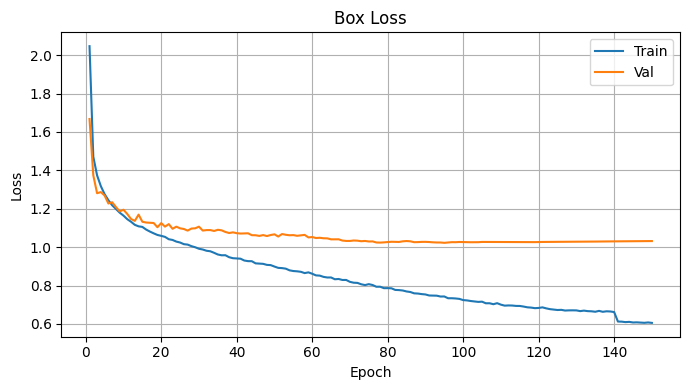

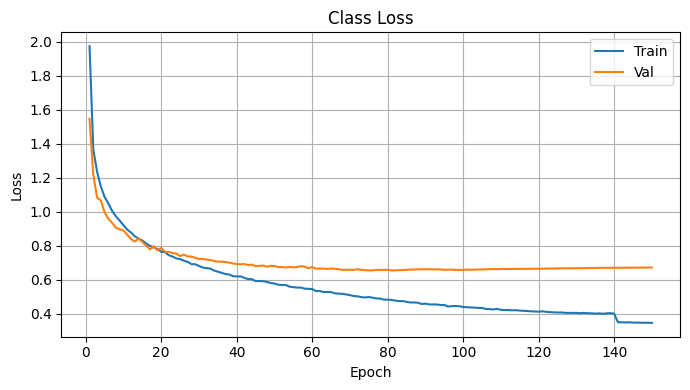

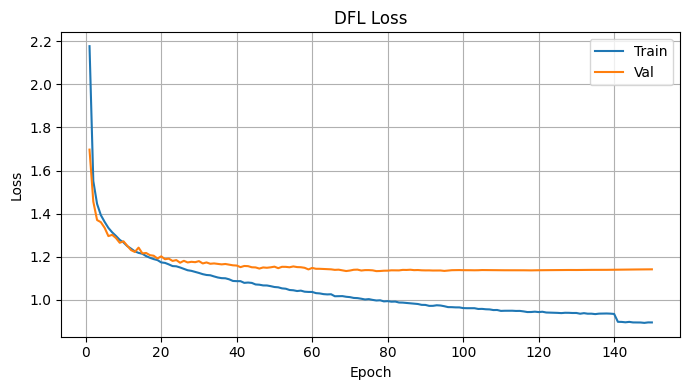

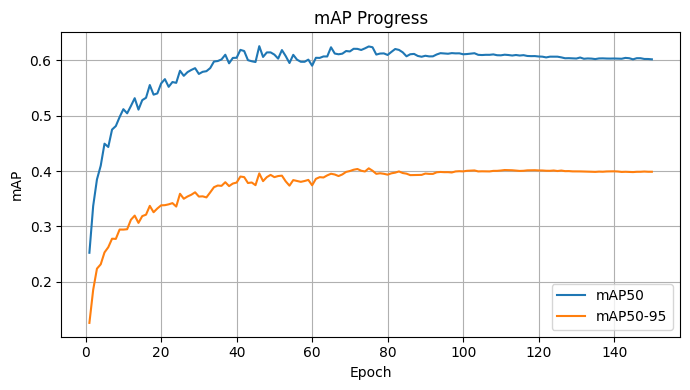

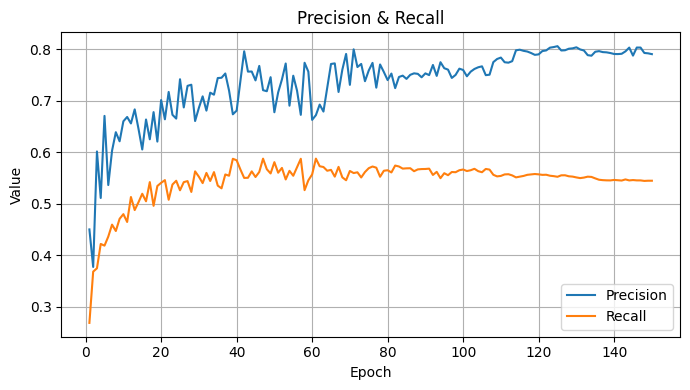

In [41]:
XP_DIR = os.path.join(PROJECT_DIR, EXP_NAME)
RESULTS_CSV = os.path.join(EXP_DIR, "results.csv")
BEST_MODEL  = os.path.join(EXP_DIR, "weights", "best.pt")

df = pd.read_csv(RESULTS_CSV)

# Loss
loss_pairs = [
    ("train/box_loss", "val/box_loss", "Box Loss"),
    ("train/cls_loss", "val/cls_loss", "Class Loss"),
    ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
]

for tr, vl, title in loss_pairs:
    plt.figure(figsize=(7,4))
    plt.plot(df["epoch"], df[tr], label="Train")
    plt.plot(df["epoch"], df[vl], label="Val")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# mAP
plt.figure(figsize=(7,4))
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.title("mAP Progress")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Precision & Recall
plt.figure(figsize=(7,4))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.title("Precision & Recall")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
print("\n=== Evaluasi pada Validation Set ===")
val_metrics = best_model.val(data=DATA_YAML, split="val")

print(f"mAP50:     {val_metrics.box.map50:.4f}")
print(f"mAP50-95:  {val_metrics.box.map:.4f}")
print(f"Precision: {val_metrics.box.mp:.4f}")
print(f"Recall:    {val_metrics.box.mr:.4f}")



=== Evaluasi pada Validation Set ===
Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,419,379 parameters, 0 gradients
val: Fast image access ✅ (ping: 6.7±10.2 ms, read: 722.9±784.7 MB/s, size: 1742.0 KB)
val: Scanning /kaggle/input/sh17-dataset-for-ppe-detection/labels... 807 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 807/807 203.1it/s 4.0s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/sh17-dataset-for-ppe-detection is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 1.7s/it 1:280.4sss
                   all        807       7643      0.751      0.571      0.626      0.404
                person        751       1355      0.892      0.865      0.896      0.725
                   ear        492        791      0.914      0.684      0.762      0.485
              ear-mufs         20         25      0.754    

In [43]:
print("\n=== Evaluasi pada Test Set ===")
test_metrics = best_model.val(data=DATA_YAML, split="test")

print(f"mAP50:     {test_metrics.box.map50:.4f}")
print(f"mAP50-95:  {test_metrics.box.map:.4f}")
print(f"Precision: {test_metrics.box.mp:.4f}")
print(f"Recall:    {test_metrics.box.mr:.4f}")



=== Evaluasi pada Test Set ===
Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 2.6±3.0 ms, read: 411.8±276.3 MB/s, size: 948.9 KB)
val: Scanning /kaggle/input/sh17-dataset-for-ppe-detection/labels... 813 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 813/813 430.0it/s 1.9s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/sh17-dataset-for-ppe-detection is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 1.7s/it 1:280.3sss
                   all        813       7715      0.744      0.582      0.627      0.408
                person        764       1379      0.896      0.872      0.906      0.726
                   ear        495        821      0.902      0.695      0.764       0.47
              ear-mufs         18         24      0.612      0.333      0.347      0.216
                  face        578        938     

## **📊 6.7 Confusion Matrix**

Menganalisis metrik evaluasi (mAP, Precision, Recall) dan menampilkan Confusion Matrix untuk model RFS.

📈 Confusion Matrix:


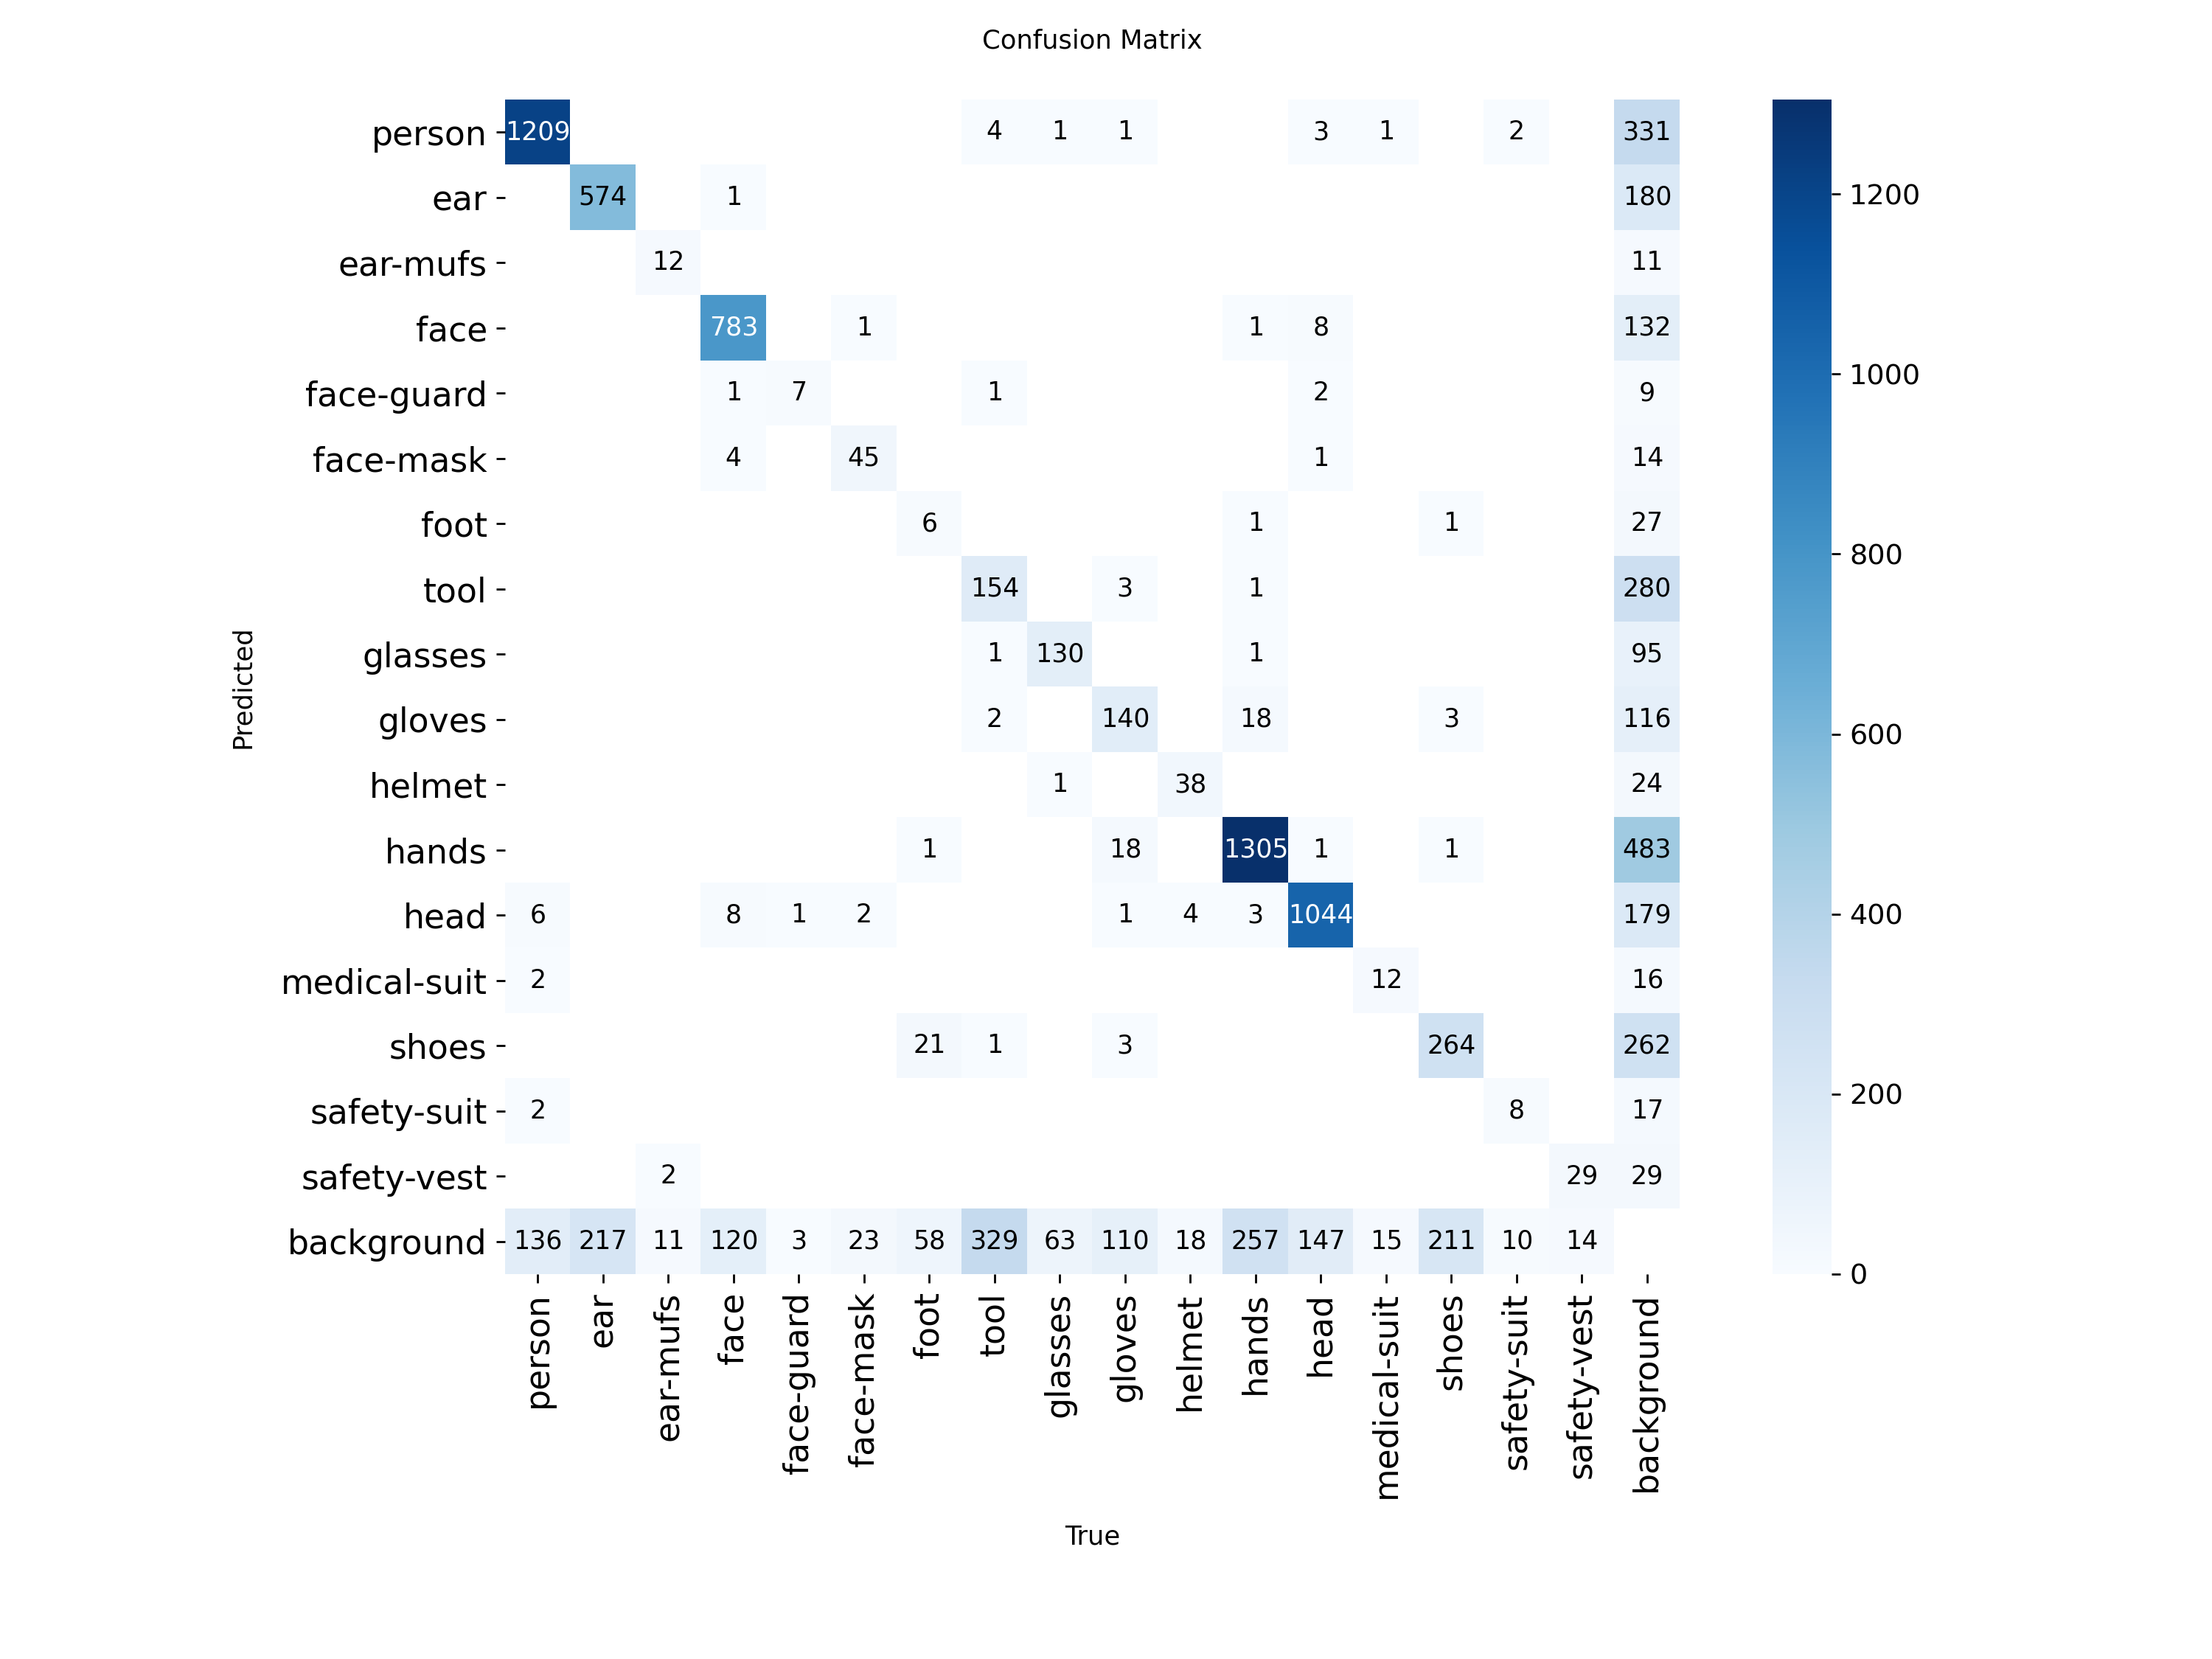

In [39]:
from IPython.display import Image, display

CM_PATH = os.path.join(EXP_DIR, "confusion_matrix.png")

if os.path.exists(CM_PATH):
    print("📈 Confusion Matrix:")
    display(Image(filename=CM_PATH))
else:
    print("⚠️ Confusion Matrix tidak ditemukan")

## **📈 6.8 SAMPLE DETECTION DARI TEST SET**

In [40]:
import matplotlib.pyplot as plt

print("\n=== Grid Deteksi 3 Sampel Pertama ===")

# ambil 3 image teratas dari daftar
k = min(3, len(test_images))
sample_imgs = test_images[:k]  # index 0,1,2

fig, axs = plt.subplots(1, k, figsize=(15, 5))

for ax, img_path in zip(axs, sample_imgs):
    res = best_model.predict(
        source=img_path,
        imgsz=IMG_SZ,
        conf=0.25,
        verbose=False
    )
    im_array = res[0].plot()[:, :, ::-1]

    ax.imshow(im_array)
    ax.set_title(os.path.basename(img_path), fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()



=== Grid Deteksi 3 Sampel Pertama ===


NameError: name 'test_images' is not defined

In [42]:
ZIP_PATH = "/kaggle/working/YOLOv11_FINAL_MODEL.zip"
!zip -r {ZIP_PATH} {EXP_DIR}

print("📦 Final model & results di-zip:", ZIP_PATH)

  adding: kaggle/working/final_model/YOLOv11_AdamW_Dropout0.1_FINAL/ (stored 0%)
  adding: kaggle/working/final_model/YOLOv11_AdamW_Dropout0.1_FINAL/train_batch0.jpg (deflated 9%)
  adding: kaggle/working/final_model/YOLOv11_AdamW_Dropout0.1_FINAL/args.yaml (deflated 52%)
  adding: kaggle/working/final_model/YOLOv11_AdamW_Dropout0.1_FINAL/BoxF1_curve.png (deflated 3%)
  adding: kaggle/working/final_model/YOLOv11_AdamW_Dropout0.1_FINAL/train_batch70560.jpg (deflated 9%)
  adding: kaggle/working/final_model/YOLOv11_AdamW_Dropout0.1_FINAL/train_batch1.jpg (deflated 9%)
  adding: kaggle/working/final_model/YOLOv11_AdamW_Dropout0.1_FINAL/confusion_matrix_normalized.png (deflated 13%)
  adding: kaggle/working/final_model/YOLOv11_AdamW_Dropout0.1_FINAL/train_batch70561.jpg (deflated 11%)
  adding: kaggle/working/final_model/YOLOv11_AdamW_Dropout0.1_FINAL/results.csv (deflated 63%)
  adding: kaggle/working/final_model/YOLOv11_AdamW_Dropout0.1_FINAL/BoxPR_curve.png (deflated 5%)
  adding: kaggl